# 01 — Keşifsel Veri Analizi (EDA)

WOFOST + OpenMeteo tarımsal ML dataseti üzerinde temel keşif.

**Strateji:** 5 GB parquet dosyasını doğrudan RAM'e almak yerine DuckDB ile sorgu tabanlı çalışıyoruz. Görseller için aggregate veya küçük sample yeterli.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb

from src.data.loader import RAW_PATH, query, load_sample, load_season_agg, schema_info

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
FIGS = '../outputs/figures/'

print('DuckDB version:', duckdb.__version__)
print('Parquet path:', RAW_PATH)

DuckDB version: 1.5.2
Parquet path: /Users/sanlilarburak/Documents/Projects/crop-yield-forecast/notebooks/../data/raw/final_hourly_pcse_dataset_multiyear.parquet


## 1. Schema ve Temel Boyutlar

In [2]:
schema_info()

,column_name,column_type,null,key,default,extra
0,DATETIME,TIMESTAMP_NS,YES,None,None,None
1,AIR_TEMP,DOUBLE,YES,None,None,None
2,AIR_HUMIDITY,DOUBLE,YES,None,None,None
3,PRECIP,DOUBLE,YES,None,None,None
4,SOIL_TEMP_0_7,DOUBLE,YES,None,None,None
5,SOIL_MOISTURE_0_7,DOUBLE,YES,None,None,None
6,DVS,DOUBLE,YES,None,None,None
7,LAI,DOUBLE,YES,None,None,None
8,TAGP,DOUBLE,YES,None,None,None
9,TWSO,DOUBLE,YES,None,None,None


In [3]:
# Toplam satır sayısı ve kapsam — DuckDB doğrudan parquet metadata'sını okur, hızlı
dims = query(f"""
    SELECT
        COUNT(*)                                          AS total_rows,
        COUNT(DISTINCT crop_name)                         AS n_crops,
        COUNT(DISTINCT (latitude, longitude))             AS n_locations,
        COUNT(DISTINCT year)                              AS n_years,
        MIN(year)                                         AS year_min,
        MAX(year)                                         AS year_max,
        COUNT(DISTINCT wav_scenario)                      AS n_scenarios,
        COUNT(DISTINCT (latitude, longitude, crop_name, year, wav_scenario)) AS n_seasons
    FROM '{RAW_PATH}'
""")
dims.T.rename(columns={0: 'değer'})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,değer
total_rows,466238736
n_crops,23
n_locations,71
n_years,11
year_min,2014
year_max,2024
n_scenarios,3
n_seasons,53184


In [4]:
# Bitki listesi
crops = query(f"SELECT DISTINCT crop_name FROM '{RAW_PATH}' ORDER BY crop_name")
print(crops['crop_name'].tolist())

['barley', 'cassava', 'chickpea', 'cotton', 'cowpea', 'fababean', 'groundnut', 'maize', 'millet', 'mungbean', 'pigeonpea', 'potato', 'rapeseed', 'rice', 'seed_onion', 'sorghum', 'soybean', 'sugarbeet', 'sugarcane', 'sunflower', 'sweetpotato', 'tobacco', 'wheat']


## 2. Hedef Değişken: `harvest_twso` & `sim_success`

In [5]:
# Sezon bazında aggregate — tekil satır başına harvest_twso hep aynı olduğu için MAX yeterli
print('Sezon özeti yükleniyor (DuckDB)...')
agg = load_season_agg()
print(f'Sezon sayısı: {len(agg):,}')
agg.head()

Sezon özeti yükleniyor (DuckDB)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sezon sayısı: 53,184


,latitude,longitude,elevation,crop_name,variety_name,year,wav_scenario,WAV,harvest_twso,sim_success,mean_temp,total_precip,mean_humidity,mean_rftra,min_rftra,max_lai,max_tagp,max_dvs,season_days
0,37.0,42.5,375.0,barley,Spring_barley_301,2014,dry,10,1070.775388,1,19.279755,607.9,52.693827,0.341341,0.0,3.898172,4472.832621,2.000000,366
1,41.0,33.5,1870.0,barley,Spring_barley_301,2014,wet,100,5787.472578,1,6.100509,858.3,71.399362,0.698274,0.0,7.194234,14783.808933,1.847967,366
2,37.0,35.0,58.0,cassava,Cassava_VanHeemst_1988,2014,wet,100,127.627421,1,18.345333,524.1,67.927576,0.336516,0.0,9.563301,8406.078385,1.550000,366
3,37.0,38.0,399.0,cassava,Cassava_VanHeemst_1988,2014,normal,50,0.302260,1,19.257103,327.0,55.504392,0.195264,0.0,4.247947,3075.317543,1.563333,366
4,37.0,39.5,542.0,cassava,Cassava_VanHeemst_1988,2014,dry,10,8.755294,1,19.290158,406.8,50.703428,0.115090,0.0,0.497963,406.756698,1.563333,366


Genel sim_success oranı: 77.9%


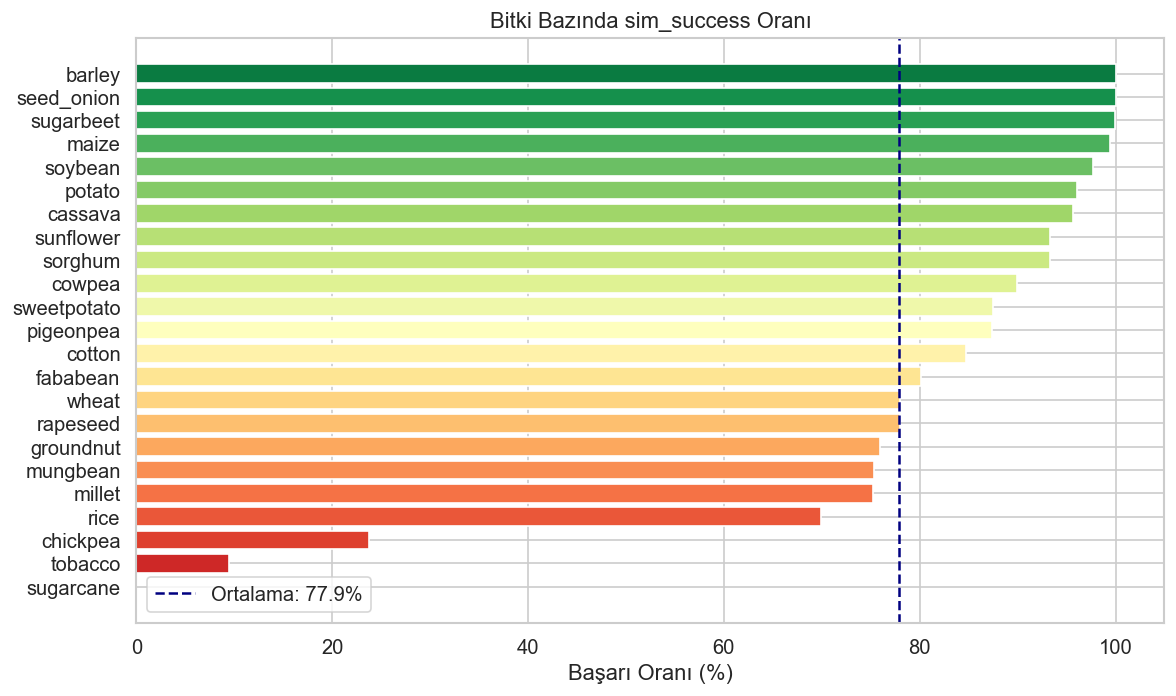

In [6]:
# sim_success oranı — genel ve bitki bazında
success_rate = agg['sim_success'].mean()
print(f'Genel sim_success oranı: {success_rate:.1%}')

by_crop = (agg.groupby('crop_name')['sim_success']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'success_rate', 'count': 'n_seasons'})
             .sort_values('success_rate'))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(by_crop.index, by_crop['success_rate'] * 100, color=sns.color_palette('RdYlGn', len(by_crop)))
ax.axvline(success_rate * 100, ls='--', color='navy', lw=1.5, label=f'Ortalama: {success_rate:.1%}')
ax.set_xlabel('Başarı Oranı (%)')
ax.set_title('Bitki Bazında sim_success Oranı')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS + 'sim_success_by_crop.png', bbox_inches='tight')
plt.show()

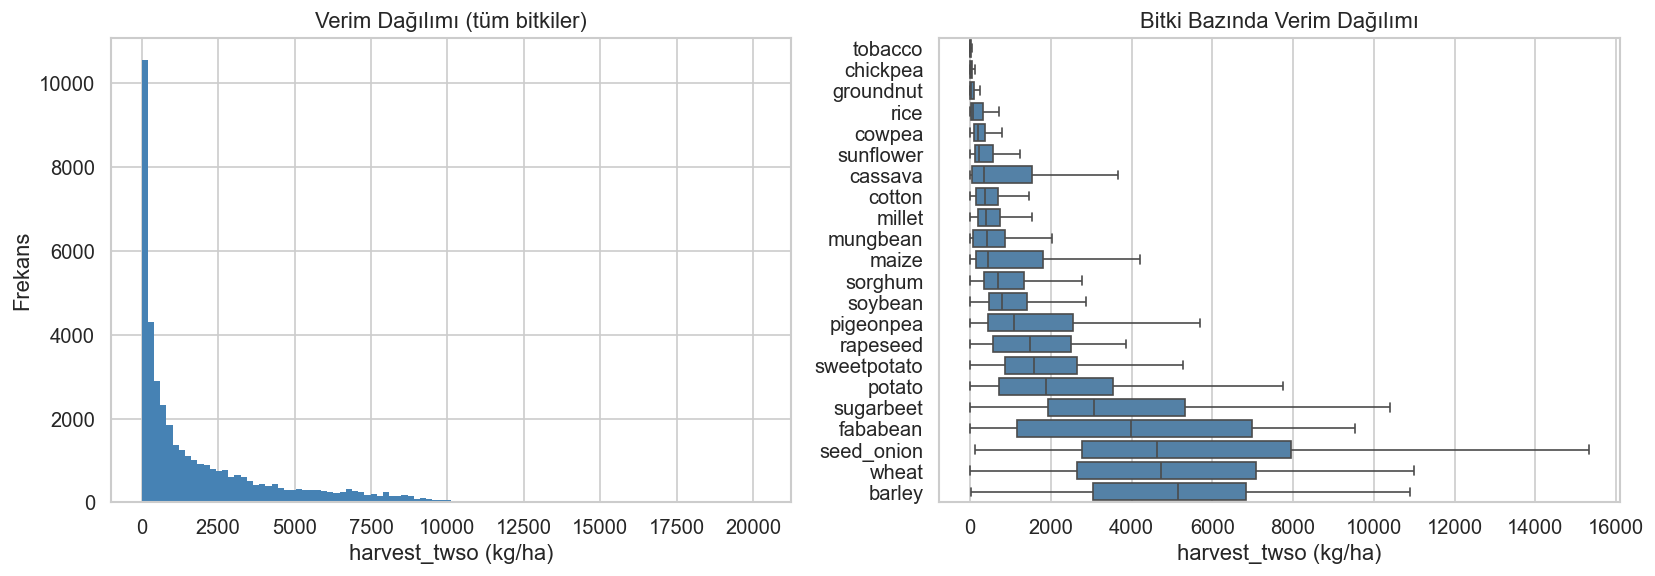

In [7]:
# Sadece başarılı hasatlar üzerinden verim dağılımı
successful = agg[agg['sim_success'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(successful['harvest_twso'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('harvest_twso (kg/ha)')
axes[0].set_ylabel('Frekans')
axes[0].set_title('Verim Dağılımı (tüm bitkiler)')

# Bitki bazında boxplot — medyana göre sıralı
order = successful.groupby('crop_name')['harvest_twso'].median().sort_values().index.tolist()
sns.boxplot(data=successful, x='harvest_twso', y='crop_name',
            order=order, showfliers=False, ax=axes[1], color='steelblue')
axes[1].set_xlabel('harvest_twso (kg/ha)')
axes[1].set_title('Bitki Bazında Verim Dağılımı')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig(FIGS + 'yield_distribution.png', bbox_inches='tight')
plt.show()

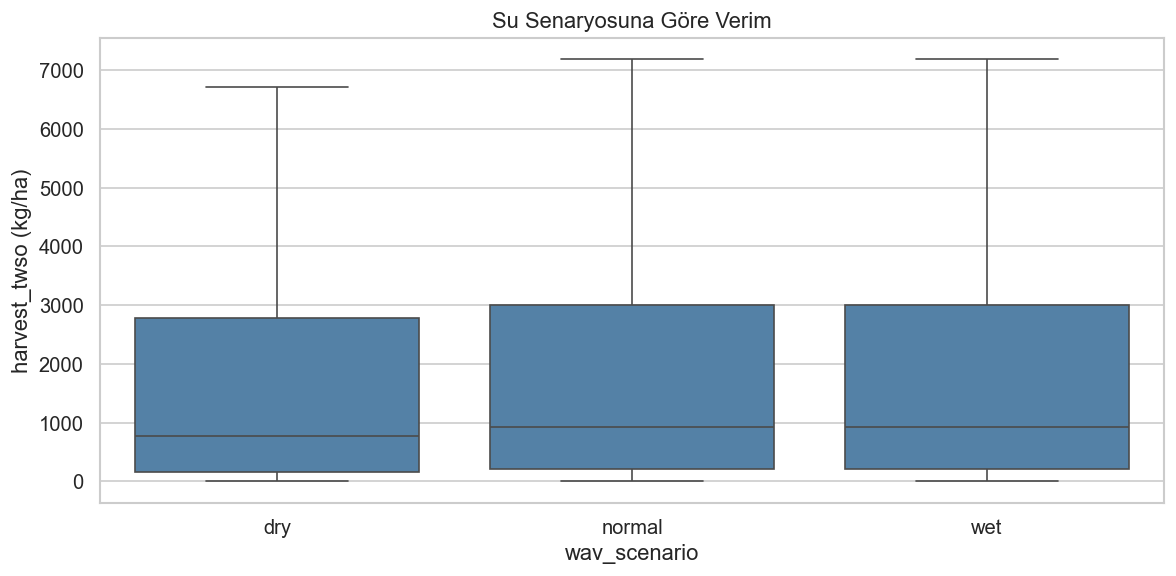

In [8]:
# WAV senaryosu etkisi: dry / normal / wet
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=successful, x='wav_scenario', y='harvest_twso',
            order=['dry', 'normal', 'wet'], showfliers=False,
            ax=ax, color='steelblue')
ax.set_title('Su Senaryosuna Göre Verim')
ax.set_xlabel('wav_scenario')
ax.set_ylabel('harvest_twso (kg/ha)')
plt.tight_layout()
plt.savefig(FIGS + 'yield_by_wav_scenario.png', bbox_inches='tight')
plt.show()

## 3. Zamansal Analiz: Yıllara Göre Verim Trendi

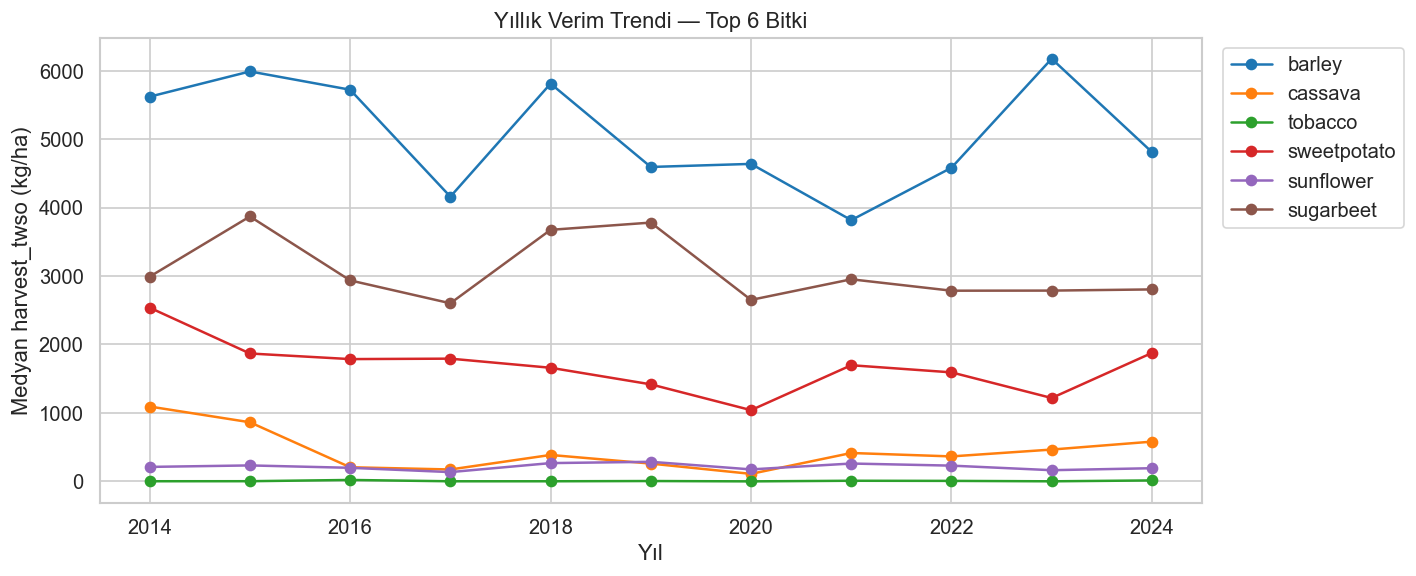

In [9]:
yearly = (successful.groupby(['year', 'crop_name'])['harvest_twso']
          .median().reset_index())

# Sadece en fazla sezona sahip 6 bitkiyi göster
top6 = (agg.groupby('crop_name').size()
           .sort_values(ascending=False).head(6).index.tolist())

fig, ax = plt.subplots(figsize=(12, 5))
for crop in top6:
    d = yearly[yearly['crop_name'] == crop]
    ax.plot(d['year'], d['harvest_twso'], marker='o', label=crop)
ax.set_xlabel('Yıl')
ax.set_ylabel('Medyan harvest_twso (kg/ha)')
ax.set_title('Yıllık Verim Trendi — Top 6 Bitki')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGS + 'yield_trend_by_year.png', bbox_inches='tight')
plt.show()

## 4. Hava Değişkenlerinin Verime Etkisi

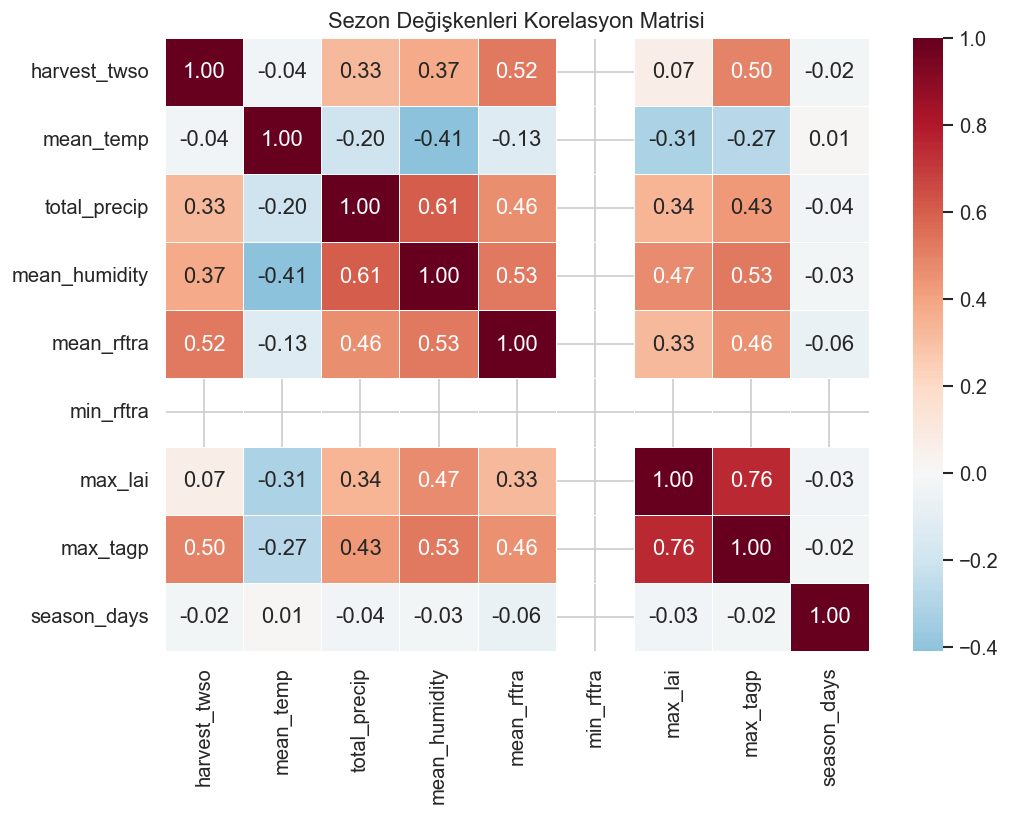

In [10]:
# Korelasyon ısı haritası (sadece başarılı hasatlar, sezon agg)
corr_cols = ['harvest_twso', 'mean_temp', 'total_precip', 'mean_humidity',
             'mean_rftra', 'min_rftra', 'max_lai', 'max_tagp', 'season_days']
corr = successful[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Sezon Değişkenleri Korelasyon Matrisi')
plt.tight_layout()
plt.savefig(FIGS + 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

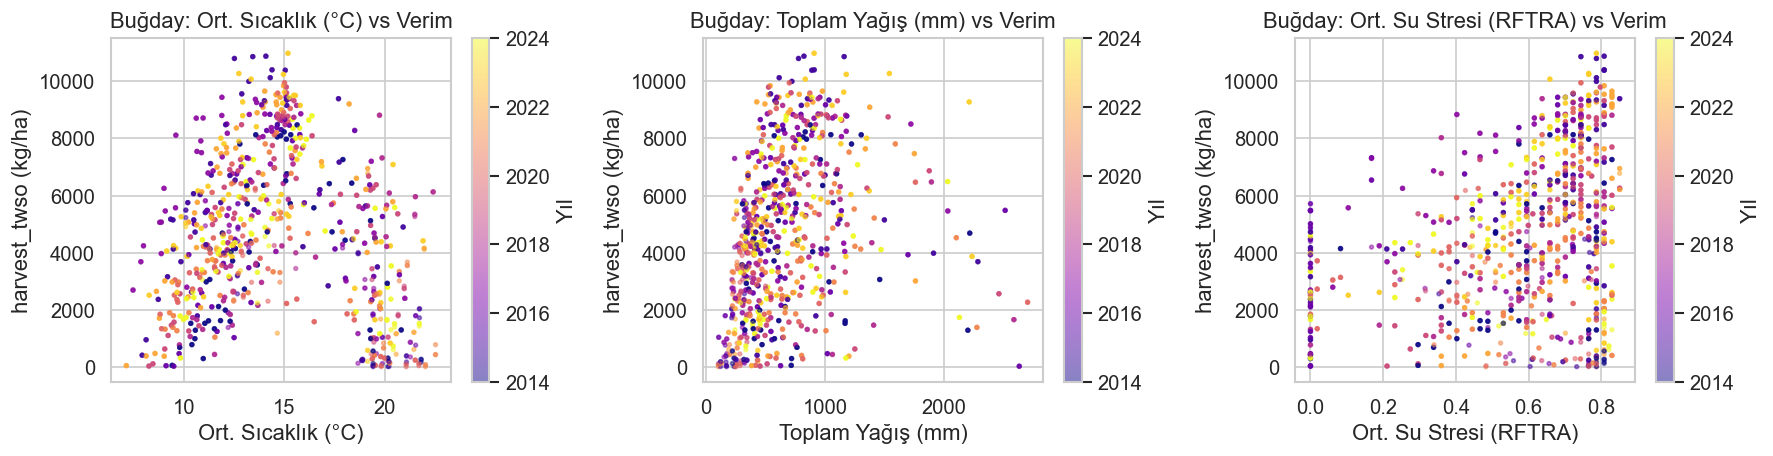

In [11]:
# Sıcaklık vs verim — scatter (wheat üzerinde örnek)
wheat = successful[successful['crop_name'] == 'wheat']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (xcol, xlabel) in zip(axes, [
    ('mean_temp', 'Ort. Sıcaklık (°C)'),
    ('total_precip', 'Toplam Yağış (mm)'),
    ('mean_rftra', 'Ort. Su Stresi (RFTRA)'),
]):
    sc = ax.scatter(wheat[xcol], wheat['harvest_twso'],
                    c=wheat['year'], cmap='plasma', s=5, alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('harvest_twso (kg/ha)')
    ax.set_title(f'Buğday: {xlabel} vs Verim')
    plt.colorbar(sc, ax=ax, label='Yıl')
plt.tight_layout()
plt.savefig(FIGS + 'wheat_weather_vs_yield.png', bbox_inches='tight')
plt.show()

## 5. Uzamsal Analiz: Türkiye Grid Haritası

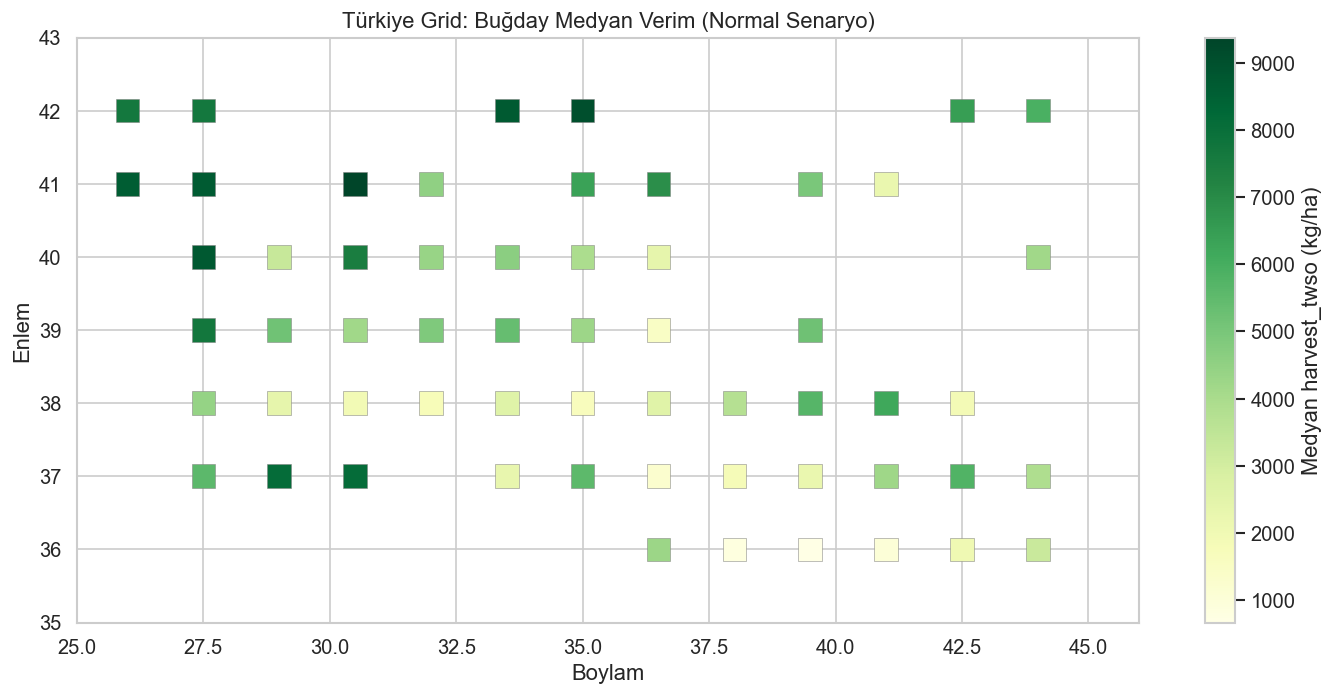

In [12]:
# Lokasyon bazında medyan verim (wheat, normal senaryo)
wheat_normal = successful[
    (successful['crop_name'] == 'wheat') &
    (successful['wav_scenario'] == 'normal')
]

loc_yield = (wheat_normal.groupby(['latitude', 'longitude'])['harvest_twso']
             .median().reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(loc_yield['longitude'], loc_yield['latitude'],
                c=loc_yield['harvest_twso'], cmap='YlGn',
                s=200, marker='s', edgecolors='gray', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='Medyan harvest_twso (kg/ha)')
ax.set_xlabel('Boylam')
ax.set_ylabel('Enlem')
ax.set_title('Türkiye Grid: Buğday Medyan Verim (Normal Senaryo)')
ax.set_xlim(25, 46)
ax.set_ylim(35, 43)
plt.tight_layout()
plt.savefig(FIGS + 'spatial_wheat_yield_map.png', bbox_inches='tight')
plt.show()

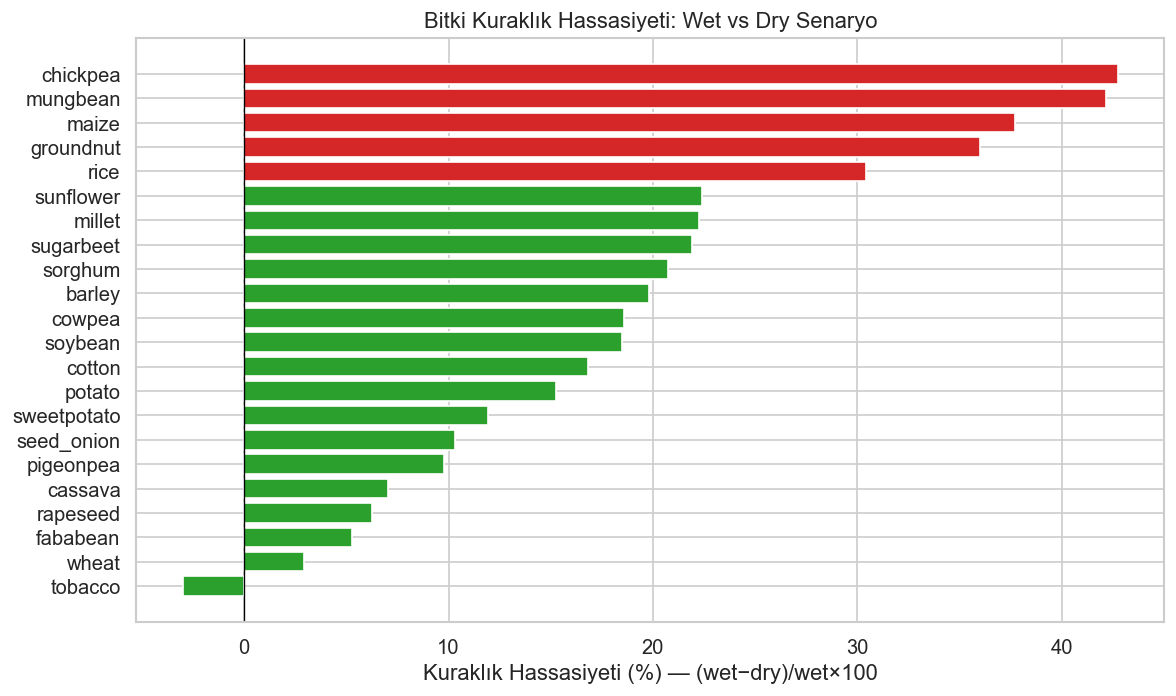

In [13]:
# Kuraklık direnci: dry vs wet senaryosu verim farkı (tüm bitkiler)
pivot = (agg[agg['sim_success'] == 1]
         .groupby(['crop_name', 'wav_scenario'])['harvest_twso']
         .median()
         .unstack('wav_scenario'))

pivot['drought_sensitivity'] = (pivot['wet'] - pivot['dry']) / pivot['wet'] * 100
pivot = pivot.sort_values('drought_sensitivity')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if v > 30 else '#2ca02c' for v in pivot['drought_sensitivity']]
ax.barh(pivot.index, pivot['drought_sensitivity'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Kuraklık Hassasiyeti (%) — (wet−dry)/wet×100')
ax.set_title('Bitki Kuraklık Hassasiyeti: Wet vs Dry Senaryo')
plt.tight_layout()
plt.savefig(FIGS + 'drought_sensitivity_by_crop.png', bbox_inches='tight')
plt.show()

## 6. Örnek Büyüme Eğrisi — Tek Sezon

In [14]:
# Tek bir sezon çek: buğday, belirli koordinat, 2020, normal
sample_season = query(f"""
    SELECT DATETIME, DVS, LAI, TAGP, TWSO, RFTRA, AIR_TEMP, PRECIP
    FROM '{RAW_PATH}'
    WHERE crop_name = 'wheat'
      AND year = 2020
      AND wav_scenario = 'normal'
      AND latitude = 39.0
      AND longitude = 35.0
    ORDER BY DATETIME
""")
sample_season['DATETIME'] = pd.to_datetime(sample_season['DATETIME'])
# Günlük indirge (forward-fill tekrarları kaldır)
daily = sample_season.set_index('DATETIME').resample('D').last().reset_index()
print(f'Sezon uzunluğu: {len(daily)} gün')
daily.head()

Sezon uzunluğu: 367 gün


,DATETIME,DVS,LAI,TAGP,TWSO,RFTRA,AIR_TEMP,PRECIP
0,2019-12-31,NaN,NaN,NaN,0.0,NaN,0.50,0.0
1,2020-01-01,NaN,NaN,NaN,0.0,NaN,-0.50,0.1
2,2020-01-02,NaN,NaN,NaN,0.0,NaN,-3.05,0.0
3,2020-01-03,NaN,NaN,NaN,0.0,NaN,-1.20,0.2
4,2020-01-04,NaN,NaN,NaN,0.0,NaN,-3.00,0.0


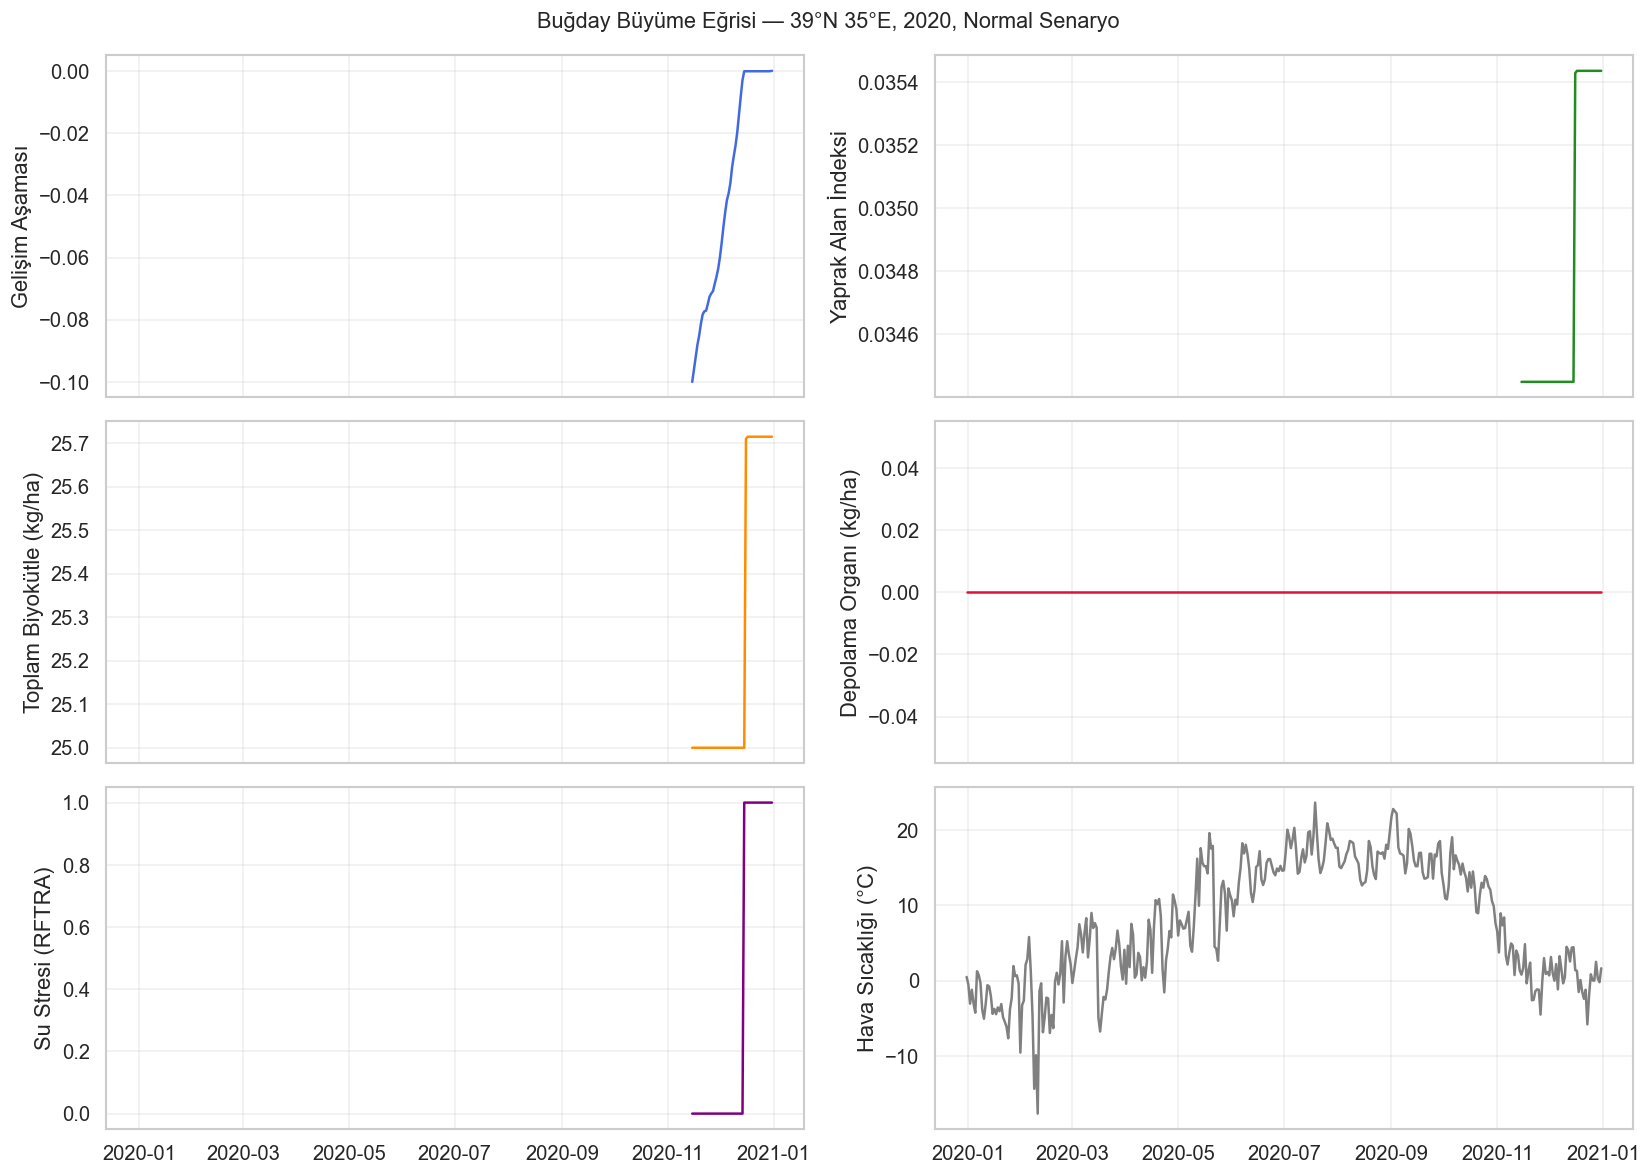

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
pairs = [
    ('DVS',     'Gelişim Aşaması',          'royalblue'),
    ('LAI',     'Yaprak Alan İndeksi',       'forestgreen'),
    ('TAGP',    'Toplam Biyokütle (kg/ha)',  'darkorange'),
    ('TWSO',    'Depolama Organı (kg/ha)',   'crimson'),
    ('RFTRA',   'Su Stresi (RFTRA)',         'purple'),
    ('AIR_TEMP','Hava Sıcaklığı (°C)',       'gray'),
]
for ax, (col, label, color) in zip(axes.flat, pairs):
    ax.plot(daily['DATETIME'], daily[col], color=color, lw=1.5)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

fig.suptitle('Buğday Büyüme Eğrisi — 39°N 35°E, 2020, Normal Senaryo', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS + 'growth_curve_wheat_sample.png', bbox_inches='tight')
plt.show()

## 7. Özet Bulgular

Buraya analiz sonrası notlar eklenecek:

- **sim_success:** Bitki bazında büyük fark var — bazı bitkiler için %50'nin altında.
- **Verim aralığı:** Bitkiye göre 500–15 000+ kg/ha arası değişiyor.
- **WAV etkisi:** Wet senaryo genelde daha yüksek verim, ancak kuraklık toleransı bitkiye göre farklı.
- **Uzamsal örüntü:** İç Anadolu vs kıyı bölgeleri arasında belirgin verim farkı bekleniyor.
- **Sonraki adım:** `02_baseline.ipynb` — wheat + normal senaryo üzerinde XGBoost baseline.